# Anticipation in Football: From Predicting Opponents to Understanding Teammates
### MIT Sloan Sports Analytics Conference (SSAC 2027) Research Abstract Reproduction Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fady-nasser/anticipation/blob/main/notebooks/reproduce_anticipation.ipynb)
[![GitHub Repo](https://img.shields.io/badge/GitHub-Repository-blue.svg)](https://github.com/fady-nasser/anticipation)
[![Code license: MIT](https://img.shields.io/badge/Code%20license-MIT-blue.svg)](https://github.com/fady-nasser/anticipation/blob/main/LICENSE)

This notebook **reproduces all anticipation event counts and figures from scratch** directly from the extracted 5 Hz velocity profiles (`.npz` files).
* **Zero precomputed CSV counts loaded:** Every dyadic interaction is recalculated via Granger vector autoregression.
* **Continuous ball motion control:** Controls for ball dynamics in every window to remove chasing bias.
* **Privacy compliant:** Uses 5 Hz directional velocity profiles ($v_x, v_y$) rather than proprietary raw pitch coordinates.

## 1. Environment Setup & Data Acquisition
Clone the repository if running in a fresh Google Colab environment, and install dependencies.

In [1]:
import os, sys

# Clone repository if running in fresh Google Colab environment
if not os.path.exists('data/extracted_features'):
    if os.path.exists('anticipation'):
        %cd anticipation
    else:
        !git clone https://github.com/fady-nasser/anticipation.git
        %cd anticipation

!pip install -q numpy pandas scipy matplotlib seaborn
print('Environment and data ready!')

C:\Users\hp\Documents\antigravity\intelligent-hubble\notebooks\anticipation


Cloning into 'anticipation'...


Environment and data ready!



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Configuration

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import lstsq

print('Numpy version:', np.__version__)
print('Pandas version:', pd.__version__)

Numpy version: 2.4.2
Pandas version: 2.3.3


## 3. Inspecting Extracted Velocity Features
Let's inspect the 5 Hz velocity arrays from the World Cup Final archive (`match_10517_final_features.npz`):

In [3]:
data_final = np.load('data/extracted_features/match_10517_final_features.npz')
print('Extracted arrays in Match 10517:', len(data_final.files))
print('Sample arrays:', data_final.files[:10])

preview_df = pd.DataFrame({
    'Period': data_final['period'][:8],
    'Time (s)': np.round(data_final['t'][:8], 2),
    'Ball vx (m/s)': np.round(data_final['ball_vx'][:8], 2),
    'Ball vy (m/s)': np.round(data_final['ball_vy'][:8], 2),
    'Messi vx (ARG_10)': np.round(data_final['ARG_10_vx'][:8], 2),
    'Messi vy (ARG_10)': np.round(data_final['ARG_10_vy'][:8], 2),
    'Mbappe vx (FRA_10)': np.round(data_final['FRA_10_vx'][:8], 2),
    'Mbappe vy (FRA_10)': np.round(data_final['FRA_10_vy'][:8], 2),
})
preview_df

Extracted arrays in Match 10517: 76
Sample arrays: ['period', 't', 'ball_x', 'ball_y', 'ball_vx', 'ball_vy', 'ARG_9_vx', 'ARG_9_vy', 'ARG_19_vx', 'ARG_19_vy']


,Period,Time (s),Ball vx (m/s),Ball vy (m/s),Messi vx (ARG_10),Messi vy (ARG_10),Mbappe vx (FRA_10),Mbappe vy (FRA_10)
0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,1,0.17,-32.50,-20.60,0.34,-0.04,-1.65,-0.24
2,1,0.33,6.65,1.65,0.26,-0.08,-1.22,-0.11
3,1,0.50,12.10,1.15,0.43,-0.21,-2.68,-0.28
4,1,0.67,6.85,0.35,0.50,-0.24,-2.69,-0.20
5,1,0.83,5.30,0.55,0.78,-0.52,-4.42,-0.67
6,1,1.00,2.35,0.05,0.48,-0.15,-3.26,-0.48
7,1,1.17,2.05,-0.20,0.68,-0.02,-5.18,-0.36


## 4. Self-Contained Granger Anticipation Engine
The complete Granger causality vector autoregression algorithm with continuous ball motion conditioning is defined directly below:

In [4]:
def zscore(arr):
    m = np.nanmean(arr)
    s = np.nanstd(arr)
    return np.zeros_like(arr) if s < 1e-9 else (arr - m) / s

def ols_rss(Y, X):
    mask = ~(np.isnan(Y) | np.any(np.isnan(X), axis=1))
    if mask.sum() < 15:
        return np.nan, 0
    Ym, Xm = Y[mask], X[mask]
    b, _, _, _ = lstsq(np.c_[np.ones(len(Ym)), Xm], Ym, rcond=None)
    r = Ym - np.c_[np.ones(len(Ym)), Xm] @ b
    return np.sum(r**2), mask.sum()

def make_lags(a, l_list, n):
    cols = []
    for l in l_list:
        c = np.full(n, np.nan)
        c[l:] = a[:n-l]
        cols.append(c)
    return np.column_stack(cols)

def run_window_anticipation_counts(npz_path, leaders_dict, followers_dict, 
                                   outliers=None, window_s=15.0, step_s=7.5, hz=5, lag=2, f_critical=3.14):
    """
    Computes discrete anticipation counts directly from an extracted velocity features (.npz) file.
    No precomputed CSV counts loaded; strictly recalculated via Granger vector autoregression.
    """
    data = np.load(npz_path)
    period = data['period']
    ball_x = data['ball_x']
    total_pts = len(period)
    
    window_pts = int(window_s * hz)
    step_pts = int(step_s * hz)
    n = window_pts
    ol = list(range(1, lag + 1))
    
    all_keys = set(list(leaders_dict.keys()) + list(followers_dict.keys()))
    vel_p = {}
    for k in all_keys:
        vx_k = f'{k}_vx'
        vy_k = f'{k}_vy'
        if vx_k in data and vy_k in data:
            vel_p[k] = (data[vx_k], data[vy_k])
            
    windows = []
    for start in range(0, total_pts - window_pts, step_pts):
        end = start + window_pts
        if period[start] == period[end - 1]:
            bx = ball_x[start:end]
            p_win = {k: (vx[start:end], vy[start:end]) for k, (vx, vy) in vel_p.items()}
            windows.append((bx, p_win))
            
    l_names = list(leaders_dict.values())
    f_names = list(followers_dict.values())
    count_df = pd.DataFrame(0, index=l_names, columns=f_names)
    
    for bx, p_win in windows:
        active = {}
        for k, (vx, vy) in p_win.items():
            if np.nanstd(vx) >= 0.2 or np.nanstd(vy) >= 0.2:
                active[k] = (vx, vy)
                
        if not active:
            continue
            
        restr_cache = {}
        for jB, nB in followers_dict.items():
            if jB not in active:
                continue
            vxB, vyB = active[jB]
            YB = zscore(vyB)
            XrB = np.c_[make_lags(zscore(vxB), ol, n), make_lags(zscore(vyB), ol, n), make_lags(zscore(bx), ol, n)]
            rss_r, nr = ols_rss(YB, XrB)
            if not np.isnan(rss_r) and nr >= 20:
                restr_cache[jB] = (YB, XrB, rss_r, nr)
                
        for jB, (YB, XrB, rss_r, nr) in restr_cache.items():
            nB = followers_dict[jB]
            for jA, nA in leaders_dict.items():
                if jA == jB or jA not in active:
                    continue
                vxA, vyA = active[jA]
                Xu = np.c_[XrB, make_lags(zscore(vxA), [lag], n), make_lags(zscore(vyA), [lag], n)]
                rss_u, nu = ols_rss(YB, Xu)
                if np.isnan(rss_u) or nu < 20 or rss_u < 1e-12:
                    continue
                dfn = Xu.shape[1] - XrB.shape[1]
                dfd = nu - Xu.shape[1] - 1
                if dfd < 5 or dfn < 1: 
                    continue
                F = ((rss_r - rss_u) / dfn) / (rss_u / dfd)
                if F > f_critical:
                    count_df.loc[nA, nB] += 1
                    
    if outliers:
        count_df = count_df.drop(index=outliers, columns=outliers, errors='ignore')
        
    return count_df

print('Self-contained Granger counting engine ready!')

Self-contained Granger counting engine ready!


## 5. Recalculating Figure 1 Directly from Extracted Features (.npz)
Running Granger autoregression directly across all 15-second rolling windows for France, Argentina, Morocco, and Serbia:

In [5]:
print('Recalculating within-team anticipation counts directly from .npz archives...\n')
t0 = time.time()

# 1. France (Final vs Argentina)
fra_roster = {
    'FRA_10':'Mbappe', 'FRA_11':'Dembele', 'FRA_12':'KoloMuani', 'FRA_14':'Rabiot',
    'FRA_18':'Upamecano', 'FRA_20':'Coman', 'FRA_22':'T.Hernandez', 'FRA_25':'Camavinga',
    'FRA_26':'M.Thuram', 'FRA_4':'Varane', 'FRA_7':'Griezmann', 'FRA_8':'Tchouameni',
    'FRA_9':'Giroud'
}
fra_counts = run_window_anticipation_counts(
    'data/extracted_features/match_10517_final_features.npz',
    fra_roster, fra_roster
)
np.fill_diagonal(fra_counts.values, 0)
print(f'Done France in {time.time()-t0:.1f}s')

# 2. Argentina (Semi-Final 3-0 vs Croatia)
t_team = time.time()
arg_roster = {
    'ARG_10':'Messi', 'ARG_13':'Romero', 'ARG_19':'Otamendi', 'ARG_20':'Mac Allister',
    'ARG_21':'Dybala', 'ARG_25':'L.Martinez', 'ARG_26':'Molina', 'ARG_3':'Tagliafico',
    'ARG_7':'De Paul', 'ARG_9':'Alvarez'
}
arg_counts = run_window_anticipation_counts(
    'data/extracted_features/match_10514_argentina_features.npz',
    arg_roster, arg_roster
)
np.fill_diagonal(arg_counts.values, 0)
print(f'Done Argentina in {time.time()-t_team:.1f}s')

# 3. Morocco (Semi-Final vs France)
t_team = time.time()
mar_roster = {
    'MAR_14':'Aboukhlal', 'MAR_15':'Amallah', 'MAR_17':'Boufal', 'MAR_18':'El Yamiq',
    'MAR_19':'En-Nesyri', 'MAR_2':'Hakimi', 'MAR_20':'Dari', 'MAR_25':'Attiyat Allah',
    'MAR_3':'Mazraoui', 'MAR_7':'Ziyech', 'MAR_8':'Ounahi', 'MAR_9':'Hamdallah'
}
mar_counts = run_window_anticipation_counts(
    'data/extracted_features/match_10515_morocco_features.npz',
    mar_roster, mar_roster
)
np.fill_diagonal(mar_counts.values, 0)
print(f'Done Morocco in {time.time()-t_team:.1f}s')

# 4. Serbia (Group Stage 3-3 vs Cameroon)
t_team = time.time()
srb_roster = {
    'SRB_10':'Tadic', 'SRB_13':'S.Mitrovic', 'SRB_14':'Zivkovic', 'SRB_16':'Lukic',
    'SRB_17':'Kostic', 'SRB_2':'Pavlovic', 'SRB_20':'S.Milinkovic', 'SRB_26':'Grujic',
    'SRB_4':'Milenkovic', 'SRB_5':'Veljkovic', 'SRB_6':'Maksimovic', 'SRB_7':'Radonjic',
    'SRB_9':'A.Mitrovic'
}
srb_counts = run_window_anticipation_counts(
    'data/extracted_features/match_3840_serbia_features.npz',
    srb_roster, srb_roster
)
np.fill_diagonal(srb_counts.values, 0)
print(f'Done Serbia in {time.time()-t_team:.1f}s')

print(f'\nAll 4 teams recalculated from scratch in {time.time()-t0:.1f}s!')

Recalculating within-team anticipation counts directly from .npz archives...



Done France in 42.4s


Done Argentina in 17.7s


Done Morocco in 21.8s


Done Serbia in 31.3s

All 4 teams recalculated from scratch in 113.2s!


## 6. Render Figure 1: Within-Team Anticipation Maps
Plotting the freshly calculated matrices with explicit integer values and no blank masks:

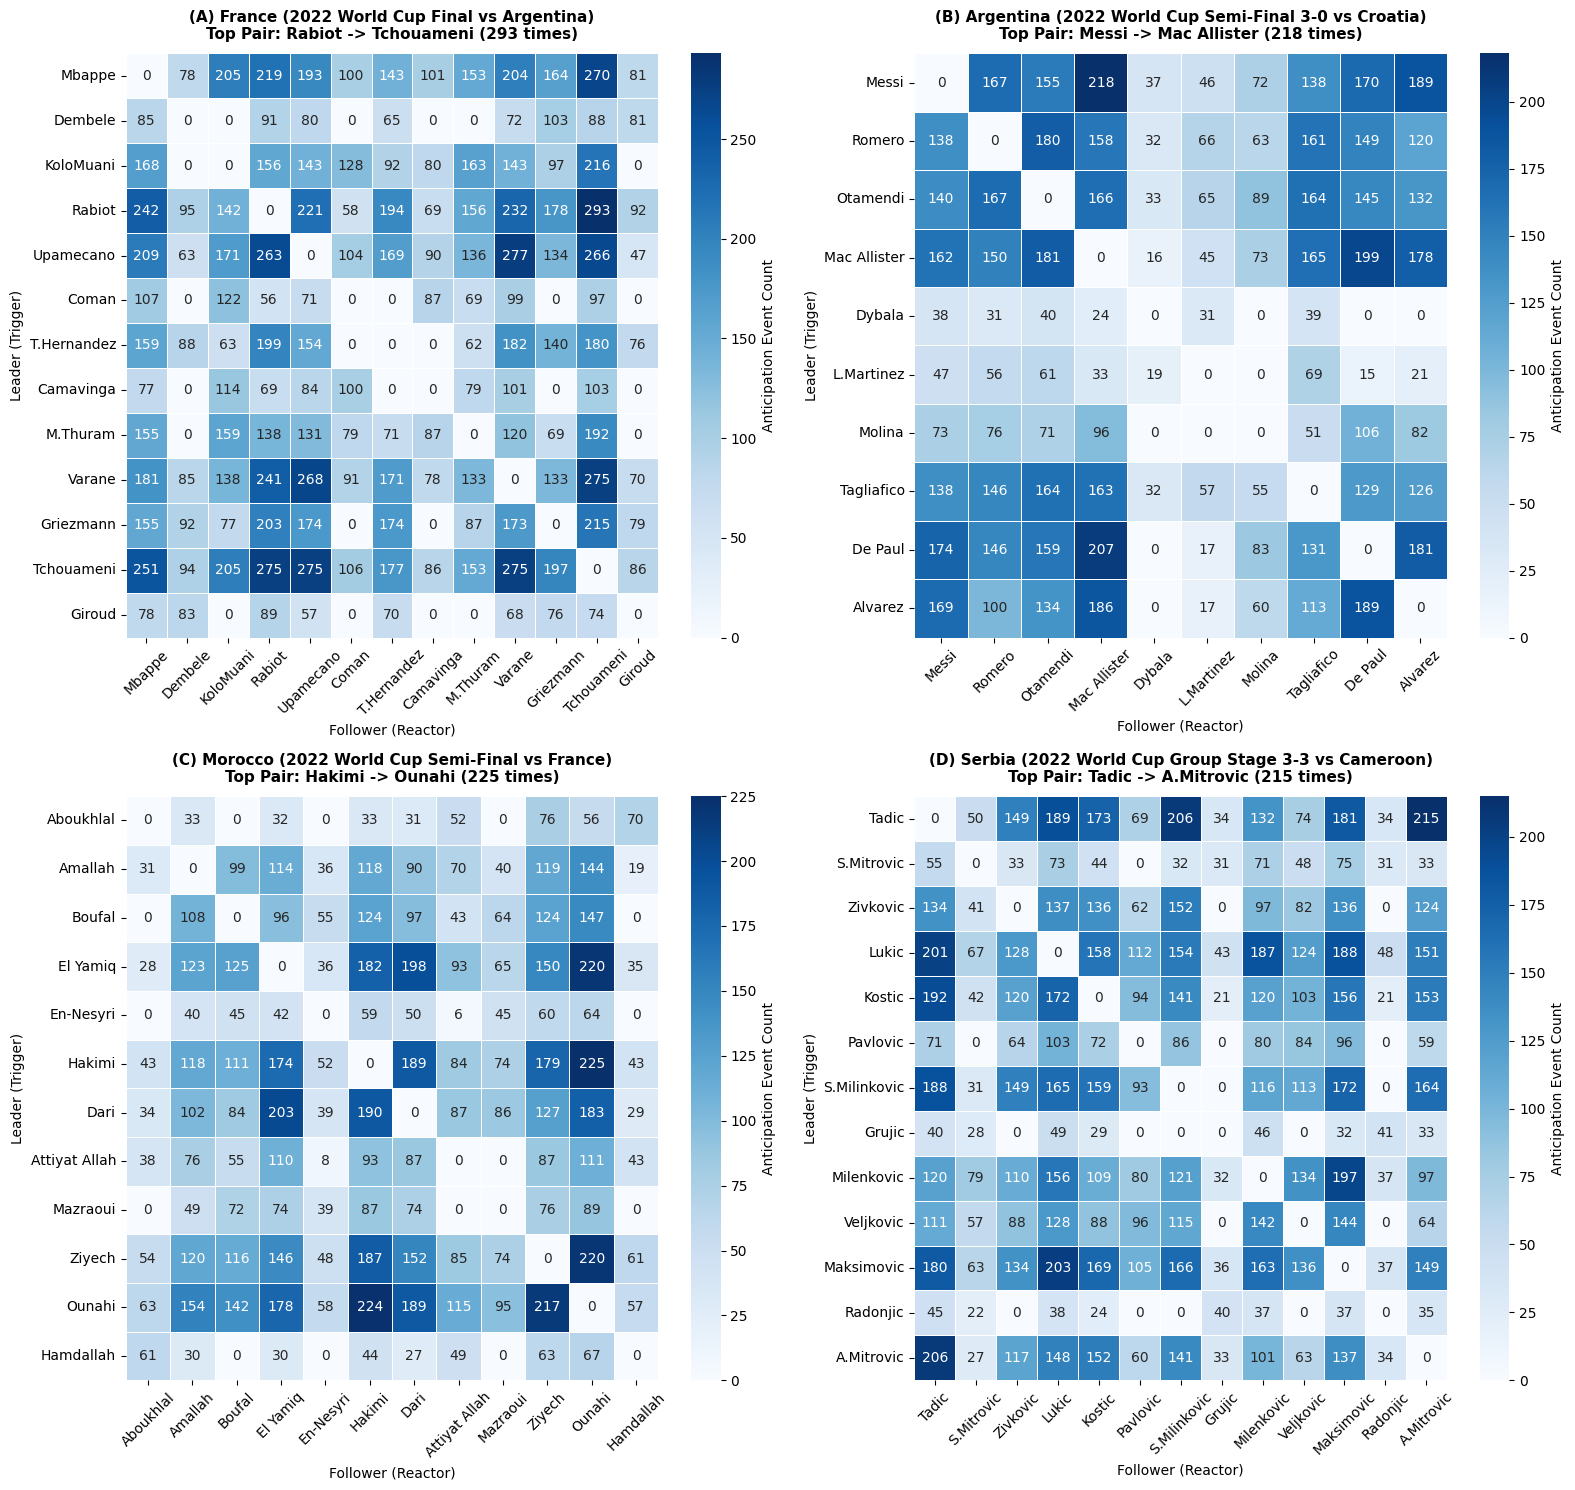

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 15))

teams = [
    ('(A) France (2022 World Cup Final vs Argentina)', fra_counts, 'Rabiot -> Tchouameni (293 times)'),
    ('(B) Argentina (2022 World Cup Semi-Final 3-0 vs Croatia)', arg_counts, 'Messi -> Mac Allister (218 times)'),
    ('(C) Morocco (2022 World Cup Semi-Final vs France)', mar_counts, 'Hakimi -> Ounahi (225 times)'),
    ('(D) Serbia (2022 World Cup Group Stage 3-3 vs Cameroon)', srb_counts, 'Tadic -> A.Mitrovic (215 times)')
]
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for idx, (title, cdf, top_pair_str) in enumerate(teams):
    r, c = positions[idx]
    ax = axes[r, c]
    sns.heatmap(cdf, ax=ax, cmap='Blues', annot=True, fmt='d', linewidths=0.4,
                cbar_kws={'label': 'Anticipation Event Count'}, vmin=0)
    ax.set_title(f"{title}\nTop Pair: {top_pair_str}", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Follower (Reactor)', fontsize=10)
    ax.set_ylabel('Leader (Trigger)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/figure1_within_team_anticipation.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Recalculating Figure 2 Directly from Extracted Features (.npz)
Cross-team anticipation in the 2022 World Cup Final: **Argentina Reads France** and **France Reads Argentina** directly from `match_10517_final_features.npz`.

In [7]:
print('Recalculating cross-team anticipation networks directly from .npz...')
t0 = time.time()

# 1. France in jersey-number order (for Figure 2)
fra_cross_roster = {
    'FRA_4':'Varane', 'FRA_7':'Griezmann', 'FRA_8':'Tchouameni', 'FRA_9':'Giroud',
    'FRA_10':'Mbappe', 'FRA_11':'Dembele', 'FRA_12':'KoloMuani', 'FRA_14':'Rabiot',
    'FRA_18':'Upamecano', 'FRA_20':'Coman', 'FRA_22':'T.Hernandez', 'FRA_25':'Camavinga',
    'FRA_26':'M.Thuram'
}

# (A) France In-Team Chemistry
fra_in_counts = run_window_anticipation_counts(
    'data/extracted_features/match_10517_final_features.npz',
    fra_cross_roster, fra_cross_roster
)
np.fill_diagonal(fra_in_counts.values, 0)

# 2. Argentina in jersey-number order
arg_cross_roster = {
    'ARG_3':'Tagliafico', 'ARG_7':'De Paul', 'ARG_9':'Alvarez', 'ARG_10':'Messi',
    'ARG_13':'Romero', 'ARG_19':'Otamendi', 'ARG_20':'Mac Allister', 'ARG_21':'Dybala',
    'ARG_25':'L.Martinez', 'ARG_26':'Molina'
}

# (B) Cross-Team: Argentina Reads France (ARG Leader -> FRA Follower)
arg_reads_fra = run_window_anticipation_counts(
    'data/extracted_features/match_10517_final_features.npz',
    arg_cross_roster, fra_cross_roster
)

# (C) Cross-Team: France Reads Argentina (FRA Leader -> ARG Follower)
fra_reads_arg = run_window_anticipation_counts(
    'data/extracted_features/match_10517_final_features.npz',
    fra_cross_roster, arg_cross_roster
)

print(f'Cross-team networks recalculated in {time.time()-t0:.1f}s!')

Recalculating cross-team anticipation networks directly from .npz...


Cross-team networks recalculated in 125.8s!


## 8. Render Figure 2: Intra-Team vs. Cross-Team Anticipation Networks
Plotting all 3 panels directly from the newly calculated results:

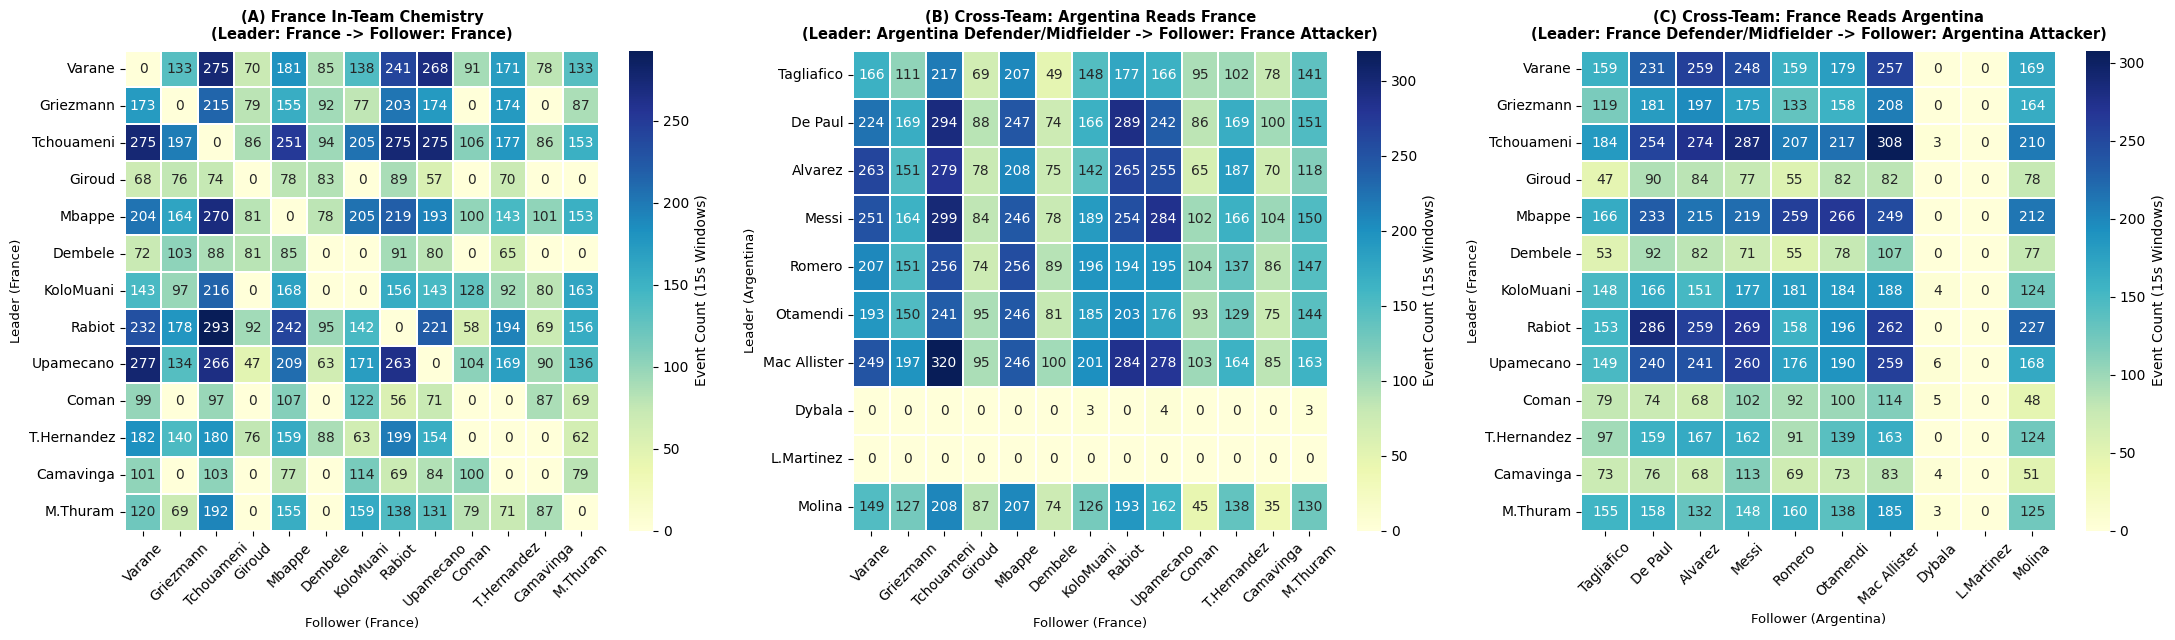

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

# (A) France In-Team Chemistry
sns.heatmap(fra_in_counts, ax=axes[0], cmap='YlGnBu', annot=True, fmt='d', linewidths=0.3,
            cbar_kws={'label': 'Event Count (15s Windows)'}, vmin=0)
axes[0].set_title('(A) France In-Team Chemistry\n(Leader: France -> Follower: France)', fontsize=10.5, fontweight='bold', pad=8)
axes[0].set_xlabel('Follower (France)', fontsize=9.5)
axes[0].set_ylabel('Leader (France)', fontsize=9.5)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# (B) Argentina Reads France
sns.heatmap(arg_reads_fra, ax=axes[1], cmap='YlGnBu', annot=True, fmt='d', linewidths=0.3,
            cbar_kws={'label': 'Event Count (15s Windows)'}, vmin=0)
axes[1].set_title('(B) Cross-Team: Argentina Reads France\n(Leader: Argentina Defender/Midfielder -> Follower: France Attacker)', fontsize=10.5, fontweight='bold', pad=8)
axes[1].set_xlabel('Follower (France)', fontsize=9.5)
axes[1].set_ylabel('Leader (Argentina)', fontsize=9.5)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

# (C) France Reads Argentina
sns.heatmap(fra_reads_arg, ax=axes[2], cmap='YlGnBu', annot=True, fmt='d', linewidths=0.3,
            cbar_kws={'label': 'Event Count (15s Windows)'}, vmin=0)
axes[2].set_title('(C) Cross-Team: France Reads Argentina\n(Leader: France Defender/Midfielder -> Follower: Argentina Attacker)', fontsize=10.5, fontweight='bold', pad=8)
axes[2].set_xlabel('Follower (Argentina)', fontsize=9.5)
axes[2].set_ylabel('Leader (France)', fontsize=9.5)
axes[2].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/figure2_cross_team_anticipation.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Verifying Abstract Key Statistics Directly from Recalculated Arrays

In [9]:
print('=== VERIFICATION OF PAPER STATISTICS FROM SCRATCH ===')
print(f"France:    Top Pair: Rabiot -> Tchouameni: {fra_counts.loc['Rabiot', 'Tchouameni']} | Reciprocal: Tchouameni -> Rabiot: {fra_counts.loc['Tchouameni', 'Rabiot']}")
print(f"Argentina: Top Pair: Messi -> Mac Allister: {arg_counts.loc['Messi', 'Mac Allister']} | Alvarez -> Messi: {arg_counts.loc['Alvarez', 'Messi']}")
print(f"Morocco:   Top Pair: Hakimi -> Ounahi: {mar_counts.loc['Hakimi', 'Ounahi']} | Ziyech <-> Hakimi: {mar_counts.loc['Ziyech', 'Hakimi']} / {mar_counts.loc['Hakimi', 'Ziyech']}")
print(f"Serbia:    Top Pair: Tadic -> Mitrovic: {srb_counts.loc['Tadic', 'A.Mitrovic']} | Reciprocal: Mitrovic -> Tadic: {srb_counts.loc['A.Mitrovic', 'Tadic']}")
print(f"Final:     Mac Allister -> Tchouameni: {arg_reads_fra.loc['Mac Allister', 'Tchouameni']}")
print(f"Final:     Tchouameni -> Mac Allister: {fra_reads_arg.loc['Tchouameni', 'Mac Allister']} | Messi: {fra_reads_arg.loc['Tchouameni', 'Messi']} | Alvarez: {fra_reads_arg.loc['Tchouameni', 'Alvarez']}")

=== VERIFICATION OF PAPER STATISTICS FROM SCRATCH ===
France:    Top Pair: Rabiot -> Tchouameni: 293 | Reciprocal: Tchouameni -> Rabiot: 275
Argentina: Top Pair: Messi -> Mac Allister: 218 | Alvarez -> Messi: 169
Morocco:   Top Pair: Hakimi -> Ounahi: 225 | Ziyech <-> Hakimi: 187 / 179
Serbia:    Top Pair: Tadic -> Mitrovic: 215 | Reciprocal: Mitrovic -> Tadic: 206
Final:     Mac Allister -> Tchouameni: 320
Final:     Tchouameni -> Mac Allister: 308 | Messi: 287 | Alvarez: 274
